Task-01: Load MNIST dataset

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist['data']
y = mnist['target']
y = y.astype(int)

Task-02: Display random 5 images

In [2]:
def display_random_images(X, y, num_images):
    indices = np.random.choice(len(X), num_images, replace=False)
    plt.figure(figsize=(10, 5))
    for i, idx in enumerate(indices):
        plt.subplot(1, num_images, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap='gray')
        plt.title(f"Label: {y[idx]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

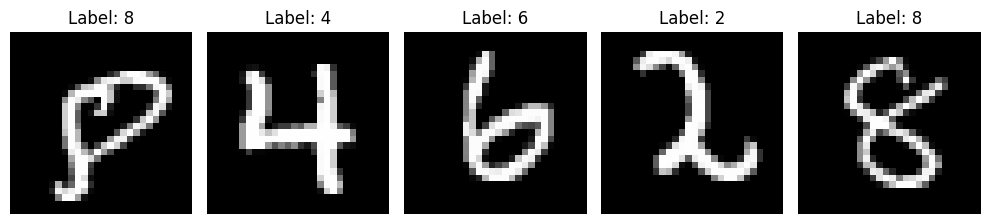

In [3]:
display_random_images(X, y,5)

Task-03: Normalize the data

In [4]:
X = X / 255.0

Task-04: Split data

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y,train_size=60000, test_size=10000, random_state=42, shuffle=True)

In [8]:
class NeuralNetwork:
    def __init__(self):
        pass

    # TASK 5: Activation and Loss functions
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
      s = self.sigmoid(x)
      return s * (1 - s)


    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def mean_squared_error(self, y_true, y_pred):
        return np.mean(np.square(y_true - y_pred))

    # TASK 6: One-hot encoding
    def one_hot_encode(self, y, num_classes=10):
        one_hot = np.zeros((len(y), num_classes))
        one_hot[np.arange(len(y)), y] = 1
        return one_hot

    # TASK 7: Initialize weights
    def initialize_weights(self, architecture=[784, 256, 128, 64, 10]):
        np.random.seed(42)
        self.weights = []
        for i in range(len(architecture) - 1):
            W = np.random.randn(architecture[i], architecture[i + 1])
            self.weights.append(W)

    # TASK 8: Forward propagation
    def forward(self, X):
        activations = [X]
        pre_activations = [None]

        for i in range(len(self.weights) - 1):
            Z = activations[-1].dot(self.weights[i])
            A = self.sigmoid(Z)
            pre_activations.append(Z)
            activations.append(A)

        Z_out = activations[-1].dot(self.weights[-1])
        A_out = self.softmax(Z_out)
        pre_activations.append(Z_out)
        activations.append(A_out)

        return activations, pre_activations

    # TASK 9: Backward propagation
    def backward(self, activations, pre_activations, y_true):
        m = y_true.shape[0]
        grads = [None] * len(self.weights)

        delta = (activations[-1] - y_true) / m
        grads[-1] = activations[-2].T.dot(delta)

        for i in reversed(range(len(self.weights) - 1)):
            dA = delta.dot(self.weights[i + 1].T)
            dZ = dA * self.sigmoid_derivative(pre_activations[i + 1])
            grads[i] = activations[i].T.dot(dZ)
            delta = dZ

        return grads

    # TASK 10: Train the network
    def train(self, X_train, y_train, epochs, batch_size, learning_rate, loss_type='mse'):
        y_train_encoded = self.one_hot_encode(y_train)

        for epoch in range(epochs):
            indices = np.arange(len(X_train))
            np.random.shuffle(indices)
            X_train_shuffled = X_train[indices]
            y_train_shuffled = y_train_encoded[indices]

            for i in range(0, len(X_train_shuffled), batch_size):
                X_batch = X_train_shuffled[i:i+batch_size]
                y_batch = y_train_shuffled[i:i+batch_size]

                activations, pre_activations = self.forward(X_batch)
                grads = self.backward(activations, pre_activations, y_batch)

                for j in range(len(self.weights)):
                    self.weights[j] -= learning_rate * grads[j]

            activations, _ = self.forward(X_train)
            if loss_type == 'mse':
                loss = self.mean_squared_error(y_train_encoded, activations[-1])
            elif loss_type == 'cross_entropy':
                loss = cross_entropy_loss(y_train_encoded, activations[-1])
            else:
                raise ValueError("Invalid loss type")

            predictions = np.argmax(activations[-1], axis=1)
            accuracy = np.mean(predictions == y_train)
            print(f'Epoch {epoch+1}: Loss={loss*100:.4f} %, Accuracy={accuracy*100:.4f} %')

    # TASK 11: Predict labels for given data
    def predict(self, X):
        activations, _ = self.forward(X)
        return np.argmax(activations[-1], axis=1)

    # Display predictions and correctness check
    def display_predictions(self, X, y, num_images=10):
      rng = np.random.default_rng()
      predictions = self.predict(X)
      indices = rng.choice(len(X), num_images, replace=False)
      n_rows = 2 if num_images > 5 else 1
      n_cols = (num_images // n_rows) + (1 if num_images % n_rows else 0)
      fig_width = min(20, n_cols * 3)
      fig_height = n_rows * 3
      plt.figure(figsize=(fig_width, fig_height))
      for i, idx in enumerate(indices):
          plt.subplot(n_rows, n_cols, i+1)
          image = X[idx].reshape(28, 28)
          pred_label = predictions[idx]
          true_label = y[idx]
          correctness = "✓ Correct" if pred_label == true_label else "✗ Incorrect"
          plt.imshow(image, cmap='gray')
          plt.title(f'Pred: {pred_label}  True: {true_label}\n {correctness}', fontsize=12)
          plt.axis('off')
      plt.tight_layout(pad=1.0)
      plt.show()


Epoch 1: Loss=4.2865 %, Accuracy=69.2933 %
Epoch 2: Loss=3.0274 %, Accuracy=78.8800 %
Epoch 3: Loss=2.4927 %, Accuracy=82.7600 %
Epoch 4: Loss=2.1344 %, Accuracy=85.3917 %
Epoch 5: Loss=1.9066 %, Accuracy=87.0433 %


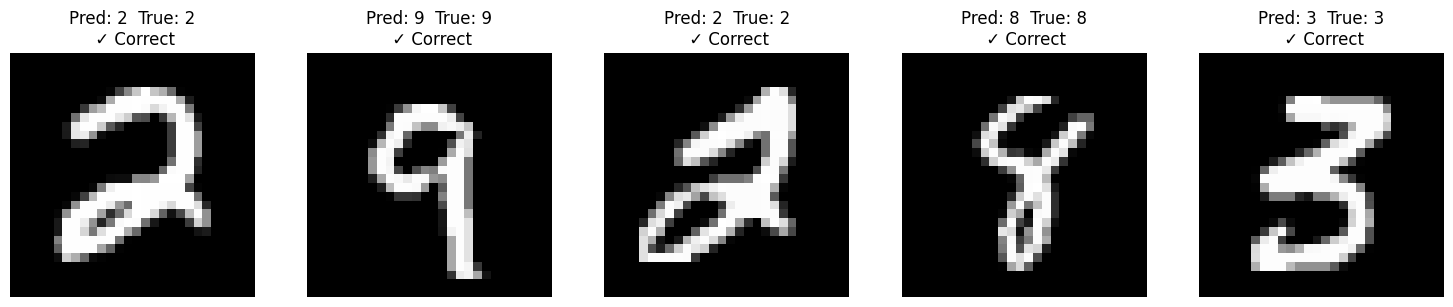

In [9]:
nn = NeuralNetwork()

nn.initialize_weights(architecture=[784, 256, 128, 64, 10])

nn.train(X_train, y_train, epochs=5, batch_size=64, learning_rate=0.1, loss_type='mse')

nn.display_predictions(X_test, y_test, num_images=5)

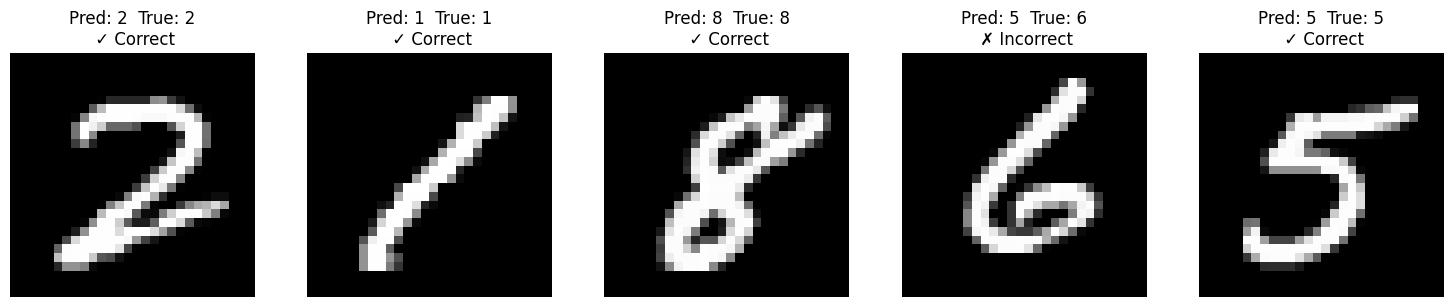

In [10]:
nn.display_predictions(X_test, y_test, num_images=5)

TASK 12-A: Different learning rates

===== TASK 12-A: Learning rate = 0.1 =====
Epoch 1: Loss=4.2865 %, Accuracy=69.2933 %
Epoch 2: Loss=3.0274 %, Accuracy=78.8800 %
Epoch 3: Loss=2.4927 %, Accuracy=82.7600 %
Epoch 4: Loss=2.1344 %, Accuracy=85.3917 %
Epoch 5: Loss=1.9066 %, Accuracy=87.0433 %


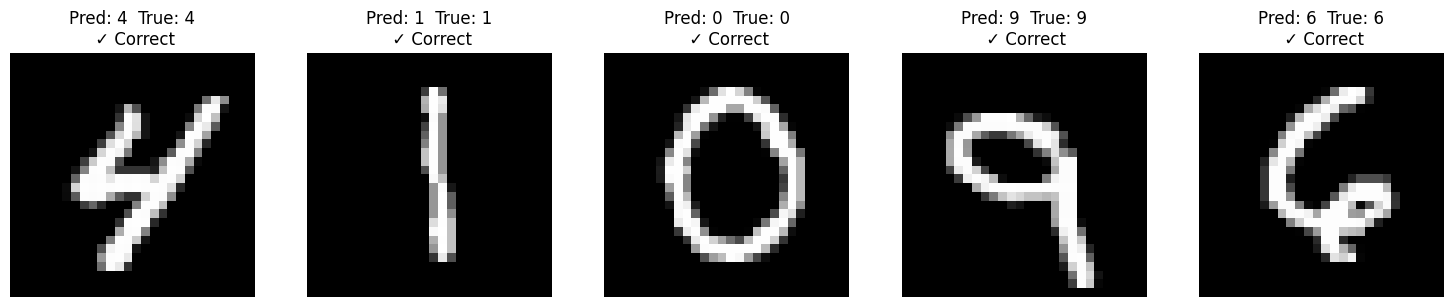

===== TASK 12-A: Learning rate = 0.01 =====
Epoch 1: Loss=8.4700 %, Accuracy=26.9083 %
Epoch 2: Loss=7.5720 %, Accuracy=37.9567 %
Epoch 3: Loss=6.8685 %, Accuracy=46.2417 %
Epoch 4: Loss=6.2675 %, Accuracy=52.3900 %
Epoch 5: Loss=5.7850 %, Accuracy=57.0700 %


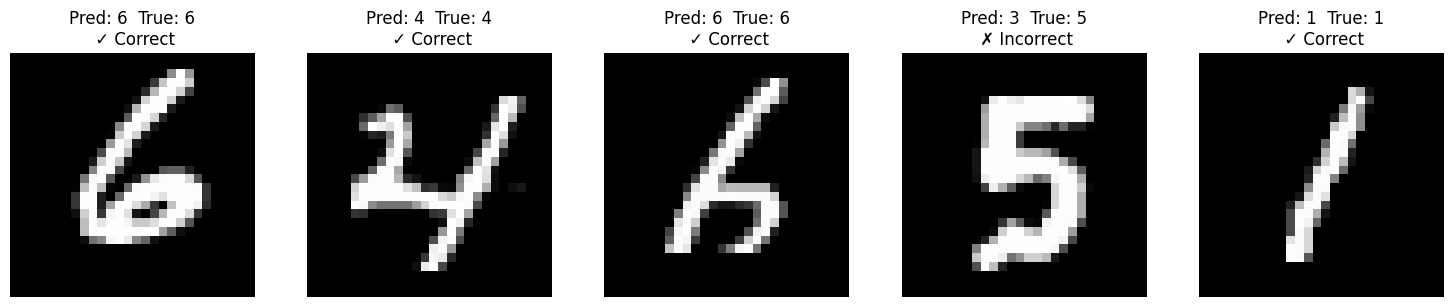

===== TASK 12-A: Learning rate = 0.001 =====
Epoch 1: Loss=11.5636 %, Accuracy=8.6350 %
Epoch 2: Loss=10.4942 %, Accuracy=11.0350 %
Epoch 3: Loss=9.9157 %, Accuracy=13.4150 %
Epoch 4: Loss=9.5522 %, Accuracy=15.5150 %
Epoch 5: Loss=9.2881 %, Accuracy=17.7683 %


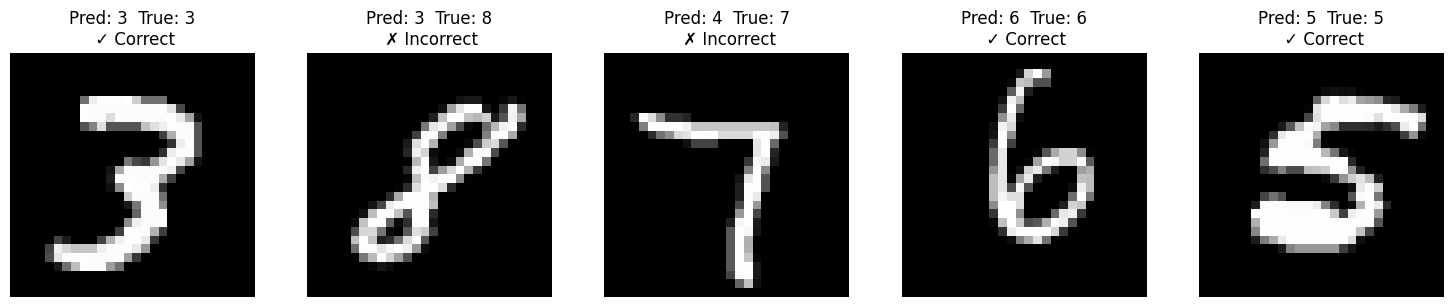

In [11]:
print("===== TASK 12-A: Learning rate = 0.1 =====")
nn = NeuralNetwork()
nn.initialize_weights([784, 256, 128, 64, 10])
nn.train(X_train, y_train, epochs=5, batch_size=64, learning_rate=0.1)
nn.display_predictions(X_test, y_test, num_images=5)
print("===== TASK 12-A: Learning rate = 0.01 =====")
nn = NeuralNetwork()
nn.initialize_weights([784, 256, 128, 64, 10])
nn.train(X_train, y_train, epochs=5, batch_size=64, learning_rate=0.01)
nn.display_predictions(X_test, y_test, num_images=5)
print("===== TASK 12-A: Learning rate = 0.001 =====")
nn = NeuralNetwork()
nn.initialize_weights([784, 256, 128, 64, 10])
nn.train(X_train, y_train, epochs=5, batch_size=64, learning_rate=0.001)
nn.display_predictions(X_test, y_test, num_images=5)

TASK 12-B: Change number of hidden layers and neurons

===== TASK 12-B: Architecture 512–256–10 =====
Epoch 1: Loss=2.8522 %, Accuracy=80.8467 %
Epoch 2: Loss=2.1265 %, Accuracy=85.5967 %
Epoch 3: Loss=1.7347 %, Accuracy=88.2550 %
Epoch 4: Loss=1.5107 %, Accuracy=89.8117 %
Epoch 5: Loss=1.3950 %, Accuracy=90.5900 %


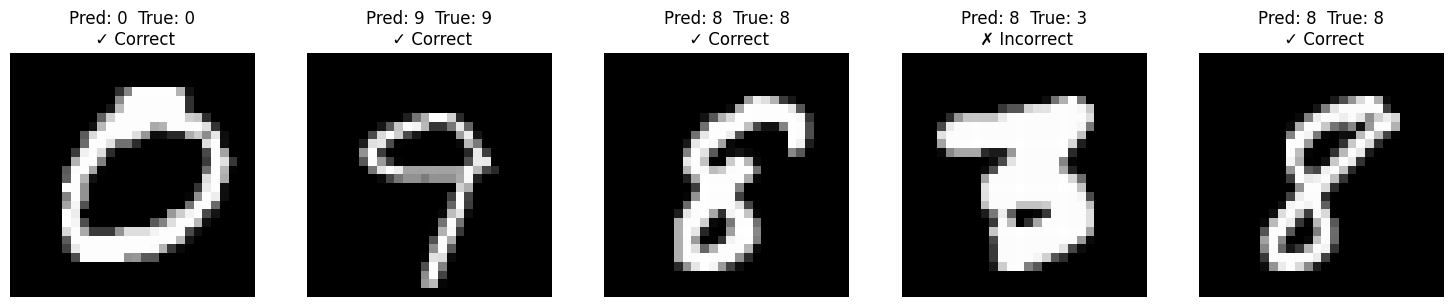

In [12]:
print("===== TASK 12-B: Architecture 512–256–10 =====")
nn = NeuralNetwork()
nn.initialize_weights([784, 512, 256, 10])
nn.train(X_train, y_train, epochs=5, batch_size=64, learning_rate=0.1)
nn.display_predictions(X_test, y_test, num_images=5)

TASK 12-C: Replace sigmoid with tanh activation in hidden layers

Epoch 1: Loss=4.3381 %, Accuracy=68.8850 %
Epoch 2: Loss=3.2824 %, Accuracy=76.8383 %
Epoch 3: Loss=2.7596 %, Accuracy=80.7233 %
Epoch 4: Loss=2.4808 %, Accuracy=82.8117 %
Epoch 5: Loss=2.1841 %, Accuracy=85.1183 %


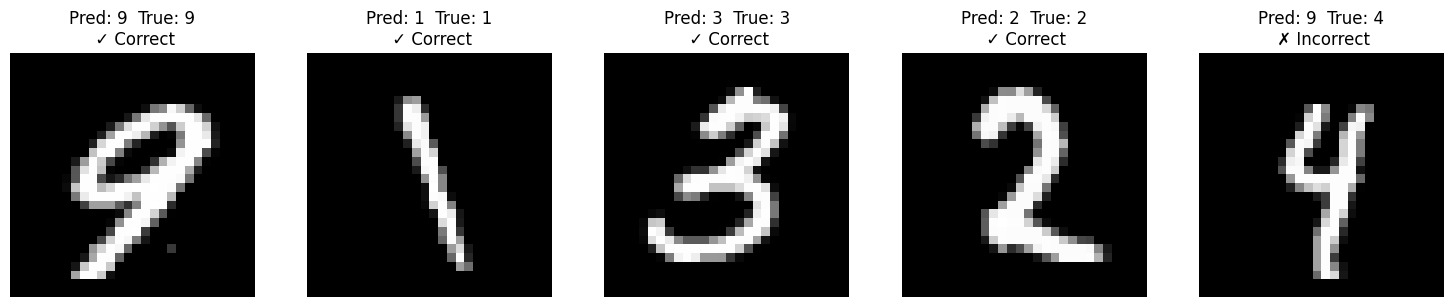

In [13]:
# New tanh activation and its derivative
def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2
# Replace activation functions in instance
nn = NeuralNetwork()
nn.sigmoid = tanh
nn.sigmoid_derivative = tanh_derivative

nn.initialize_weights([784, 256, 128, 64, 10])
nn.train(X_train, y_train, epochs=5, batch_size=64, learning_rate=0.1)
nn.display_predictions(X_test, y_test, num_images=5)

TASK 12-D: Use Cross-Entropy Loss instead of MSE

Epoch 1: Loss=95.1384 %, Accuracy=69.2933 %
Epoch 2: Loss=66.4342 %, Accuracy=78.8800 %
Epoch 3: Loss=54.5348 %, Accuracy=82.7600 %
Epoch 4: Loss=46.7788 %, Accuracy=85.3917 %
Epoch 5: Loss=41.8479 %, Accuracy=87.0433 %


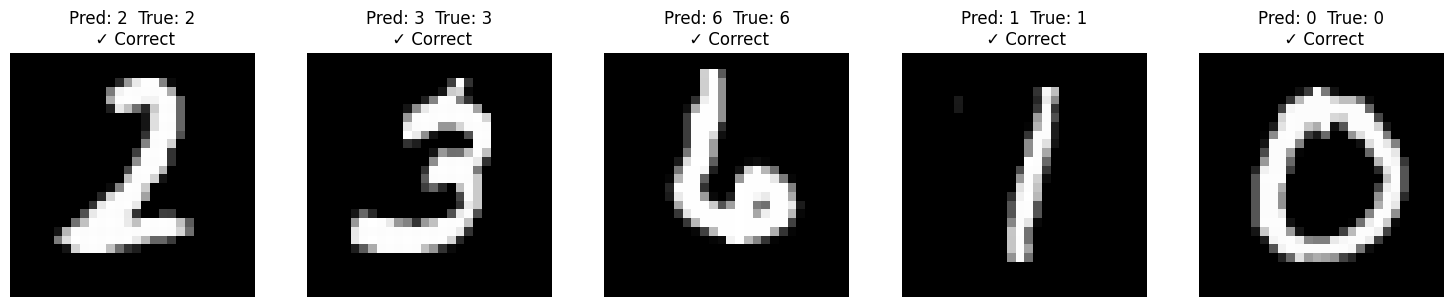

In [14]:
def cross_entropy_loss(y_true, y_pred):
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

nn = NeuralNetwork()
nn.initialize_weights([784, 256, 128, 64, 10])
nn.train(X_train, y_train, epochs=5, batch_size=64, learning_rate=0.1, loss_type='cross_entropy')
nn.display_predictions(X_test, y_test, num_images=5)

TASK 12-E: Experiment with simple and deeper architectures

===== TASK 12-E: Architecture 784–10 =====
Epoch 1: Loss=3.3748 %, Accuracy=78.8500 %
Epoch 2: Loss=2.6467 %, Accuracy=83.2317 %
Epoch 3: Loss=2.3183 %, Accuracy=85.2383 %
Epoch 4: Loss=2.1476 %, Accuracy=86.2767 %
Epoch 5: Loss=2.0076 %, Accuracy=87.1983 %


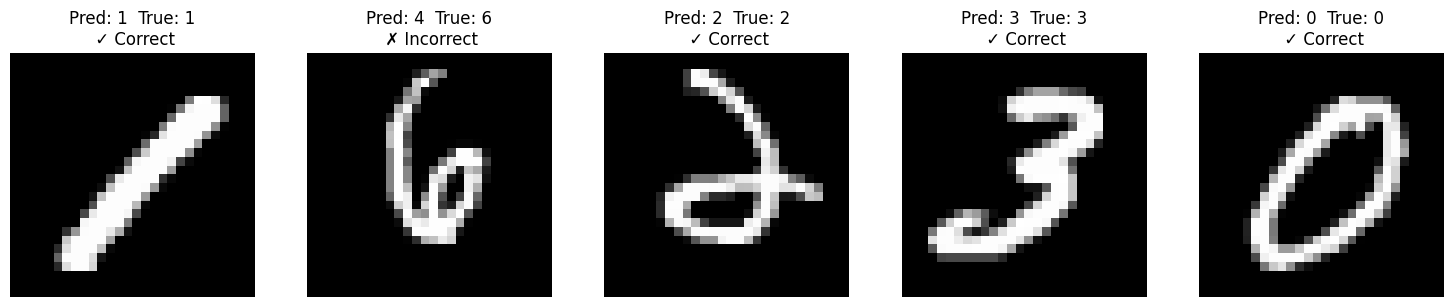

===== TASK 12-E: Architecture 784–64–10 =====
Epoch 1: Loss=3.4445 %, Accuracy=75.8550 %
Epoch 2: Loss=2.6693 %, Accuracy=81.5200 %
Epoch 3: Loss=2.2812 %, Accuracy=84.3017 %
Epoch 4: Loss=2.0480 %, Accuracy=86.0300 %
Epoch 5: Loss=1.9101 %, Accuracy=86.9433 %


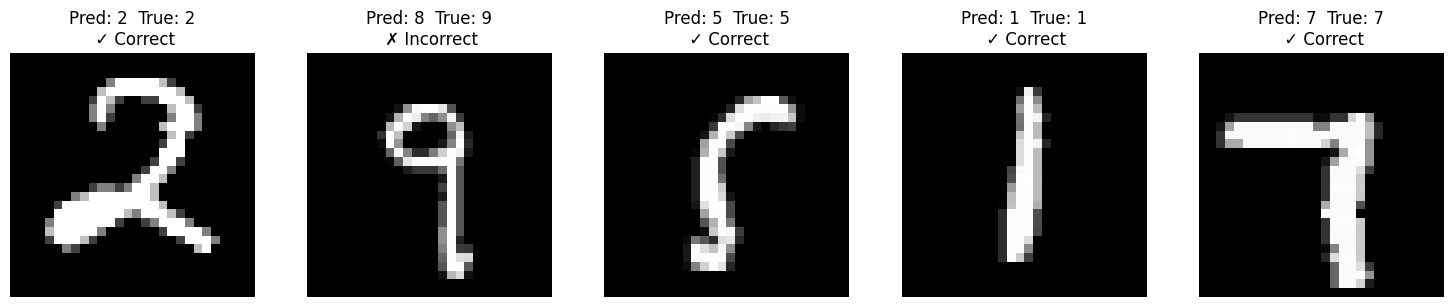

===== TASK 12-E: Architecture 784–128–10 =====
Epoch 1: Loss=3.0939 %, Accuracy=79.2333 %
Epoch 2: Loss=2.3832 %, Accuracy=84.0600 %
Epoch 3: Loss=2.0085 %, Accuracy=86.4500 %
Epoch 4: Loss=1.8023 %, Accuracy=87.8267 %
Epoch 5: Loss=1.6632 %, Accuracy=88.8017 %


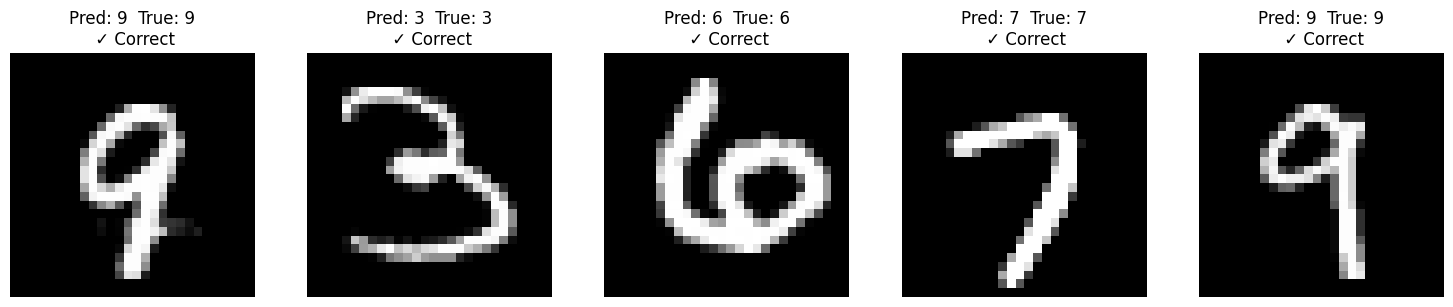

In [15]:
print("===== TASK 12-E: Architecture 784–10 =====")
nn = NeuralNetwork()
nn.initialize_weights([784, 10])
nn.train(X_train, y_train, epochs=5, batch_size=64, learning_rate=0.1)
nn.display_predictions(X_test, y_test, num_images=5)
print("===== TASK 12-E: Architecture 784–64–10 =====")
nn = NeuralNetwork()
nn.initialize_weights([784, 64, 10])
nn.train(X_train, y_train, epochs=5, batch_size=64, learning_rate=0.1)
nn.display_predictions(X_test, y_test, num_images=5)
print("===== TASK 12-E: Architecture 784–128–10 =====")
nn = NeuralNetwork()
nn.initialize_weights([784, 128, 10])
nn.train(X_train, y_train, epochs=5, batch_size=64, learning_rate=0.1)
nn.display_predictions(X_test, y_test, num_images=5)


========== Task 13: Model Evaluation ==========

Confusion Matrix:


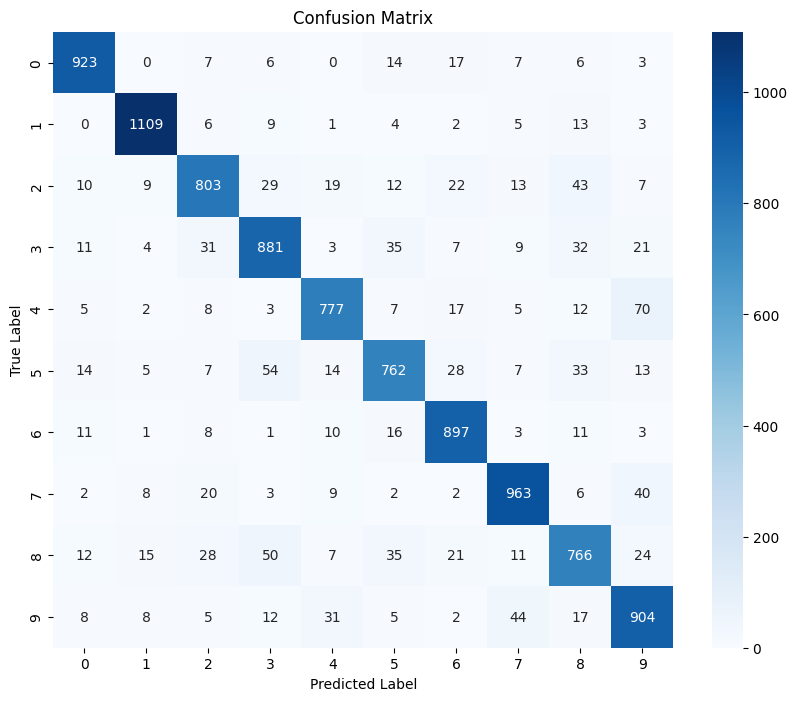


Accuracy: 87.85 %
Macro Precision: 87.7181 %
Macro Recall: 87.6421 %
Macro F1-Score: 87.6520 %

========== Interpretation of Results ==========
The confusion matrix shows how many times each digit (0-9) was correctly or incorrectly classified.
Diagonal values (top-left to bottom-right) represent correct predictions; off-diagonal values show mistakes.

Overall Accuracy: 87.85%
- High accuracy indicates strong model performance.

Macro Precision: 0.8772 → Measures the quality of positive predictions per class.
Macro Recall: 0.8764 → Measures how well actual classes are recovered.
Macro F1 Score: 0.8765 → Balances Precision and Recall per class.

Macro averaging gives equal weight to all classes (even rare ones).
High scores across Precision, Recall, and F1 show balanced and robust classification for all digits.

========== Evaluation Complete ==========



In [ ]:
print("\n========== Task 13: Model Evaluation ==========")

# Predict on test set
y_pred = nn.predict(X_test)

# 1. Confusion Matrix
print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy*100:.2f} %")

# 3. Precision, Recall, F1-Score (Macro Averaged)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Macro Precision: {precision*100:.4f} %")
print(f"Macro Recall: {recall*100:.4f} %")
print(f"Macro F1-Score: {f1*100:.4f} %")

# 4. Interpretation
print("\n========== Interpretation of Results ==========")
print("The confusion matrix shows how many times each digit (0-9) was correctly or incorrectly classified.")
print("Diagonal values (top-left to bottom-right) represent correct predictions; off-diagonal values show mistakes.")
print(f"\nOverall Accuracy: {accuracy * 100:.2f}%")
print("- High accuracy indicates strong model performance.")
print(f"\nMacro Precision: {precision:.4f} → Measures the quality of positive predictions per class.")
print(f"Macro Recall: {recall:.4f} → Measures how well actual classes are recovered.")
print(f"Macro F1 Score: {f1:.4f} → Balances Precision and Recall per class.")
print("\nMacro averaging gives equal weight to all classes (even rare ones).")
print("High scores across Precision, Recall, and F1 show balanced and robust classification for all digits.")

print("\n========== Evaluation Complete ==========\n")